<a href="https://colab.research.google.com/github/shravaniphalke805/Python-Libraries/blob/main/assignment17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving heart - heart.csv to heart - heart.csv


In [3]:
df = pd.read_csv("heart - heart.csv")

In [4]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [5]:
df.shape

(918, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [8]:
# Check for duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

# Remove duplicate rows if found
if duplicates > 0:
    df = df.drop_duplicates()

# Print new shape of the dataset
print("Shape after removing duplicates:")
print(df.shape)

Number of duplicate rows: 0
Shape after removing duplicates:
(918, 12)


In [10]:
# Count rows where Cholesterol is 0
cholesterol_zero = (df['Cholesterol'] == 0).sum()

# Count rows where RestingBP is 0
restingbp_zero = (df['RestingBP'] == 0).sum()

# Print counts
print("Number of rows with Cholesterol = 0:", cholesterol_zero)
print("Number of rows with RestingBP = 0:", restingbp_zero)

Number of rows with Cholesterol = 0: 172
Number of rows with RestingBP = 0: 1


In [13]:
# Statistical summary before cleaning
print("Before Cleaning:")
print(df[['Cholesterol', 'RestingBP']].describe())

# Ensure columns are float type before replacement to avoid future warnings
df['Cholesterol'] = df['Cholesterol'].astype(float)
df['RestingBP'] = df['RestingBP'].astype(float)

# Calculate mean values excluding zeros
mean_chol = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
mean_trestbps = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()

# Replace zero values with mean values
df.loc[df['Cholesterol'] == 0, 'Cholesterol'] = mean_chol
df.loc[df['RestingBP'] == 0, 'RestingBP'] = mean_trestbps

# Round columns to 2 decimal places
df['Cholesterol'] = df['Cholesterol'].round(2)
df['RestingBP'] = df['RestingBP'].round(2)

# Statistical summary after cleaning
print("\nAfter Cleaning:")
print(df[['Cholesterol', 'RestingBP']].describe())

Before Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

After Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


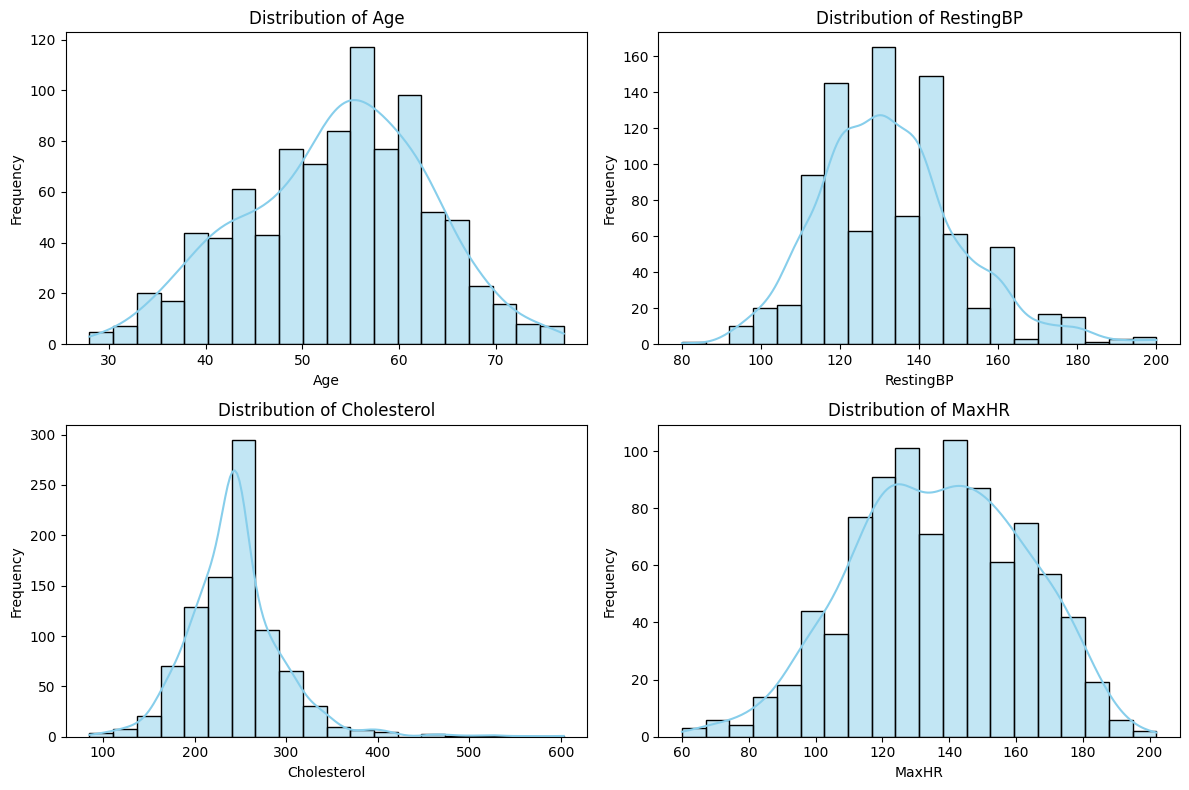

In [15]:
# Function to plot histograms
def plot_histograms(data, columns):
    plt.figure(figsize=(12, 8))

    for i, column in enumerate(columns):
        plt.subplot(2, 2, i+1)
        sns.histplot(data[column], bins=20, kde=True, color='skyblue')

        plt.title(f"Distribution of {column}")
        plt.xlabel(column)
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Columns to visualize
hist_columns = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']

# Call the function
plot_histograms(df, hist_columns)

In [16]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Print numerical columns
print("Numerical Columns:")
print(list(numerical_columns))

# Print categorical columns
print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']

Categorical Columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [17]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Perform One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_columns)

# Print shape of encoded dataframe
print("Shape of Encoded Dataset:")
print(df_encoded.shape)

# Display first 5 rows
print("\nFirst 5 Rows of Encoded Dataset:")
print(df_encoded.head())

Shape of Encoded Dataset:
(918, 21)

First 5 Rows of Encoded Dataset:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

In [18]:
# Print final shape of encoded dataframe
print("Final Shape of df_encoded:")
print(df_encoded.shape)

# Print all column names
print("\nColumns in df_encoded:")
print(list(df_encoded.columns))

Final Shape of df_encoded:
(918, 21)

Columns in df_encoded:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
